In [1]:
import argparse
from pathlib import Path

import gerrychain
import networkx as nx
import pandas as pd

In [ ]:
# Calculate metrics for one manually selected cluster-year area

# selections csv
selections = pd.read_csv('data/candidate_tracts.csv')
selections.head(2)

,cbsa,metro,year,candidate_id,cluster,selection_method,connectivity_rule,core_selection_rule,neighbor_rule,definition_year,...,geoid,statefp,countyfp,black_population,total_population,black_share,meets_core_threshold,is_core,centroid_x,centroid_y
0,16980,"Chicago-Naperville-Elgin, IL-IN-WI",1980,16980_1980_01,hyde_park,fixed_2020_footprint_plus_annual_core_neighbor...,largest_geographic_rook_component_by_black_pop...,largest_geographic_rook_core_component_by_blac...,connected_graph_edge_and_geographic_rook_adjac...,2020,...,17003103301,17,31,1726,1981,0.871277,True,False,690073.837202,518940.484824
1,16980,"Chicago-Naperville-Elgin, IL-IN-WI",1980,16980_1980_01,hyde_park,fixed_2020_footprint_plus_annual_core_neighbor...,largest_geographic_rook_component_by_black_pop...,largest_geographic_rook_core_component_by_blac...,connected_graph_edge_and_geographic_rook_adjac...,2020,...,17003103302,17,31,1724,1777,0.970174,True,False,689006.540840,518941.805366


In [19]:
selections.columns

Index(['cbsa', 'metro', 'year', 'candidate_id', 'cluster', 'selection_method',
       'connectivity_rule', 'core_selection_rule', 'neighbor_rule',
       'definition_year', 'definition_candidate_id', 'catchment_threshold',
       'core_threshold', 'in_definition_candidate', 'in_definition_core',
       'meets_definition_core_threshold', 'is_definition_buffer',
       'buffer_overlap_tiebreak', 'in_fixed_footprint',
       'is_annual_core_neighbor', 'annual_overlap_tiebreak', 'node_id',
       'gisjoin', 'geoid', 'statefp', 'countyfp', 'black_population',
       'total_population', 'black_share', 'meets_core_threshold', 'is_core',
       'centroid_x', 'centroid_y'],
      dtype='object')

In [ ]:
def calculate_cluster_metrics(
    graph, gisjoins, core_gisjoins):
    """Calculate metrics for one supplied cluster-year catchment and core."""
    # Translate the supplied catchment and core GISJOINs to graph node IDs.
    nodes_by_gisjoin = {
        str(attrs["GISJOIN"]): node for node, attrs in graph.nodes(data=True)
    }
    selected_nodes = [nodes_by_gisjoin[gisjoin] for gisjoin in gisjoins]
    core_nodes = [nodes_by_gisjoin[gisjoin] for gisjoin in core_gisjoins]

    # Sum the population contained in the supplied catchment.
    black_population = sum(int(graph.nodes[node]["BLACK"]) for node in selected_nodes)
    print(f"Black population in catchment: {black_population}")
    total_population = sum(int(graph.nodes[node]["TOTPOP"]) for node in selected_nodes)
    print(f"Total population in catchment: {total_population}")

    # Test every catchment tract and retain the weighted graph centroid
    best_center = None
    best_objective = None

    for candidate in selected_nodes:
        distances = nx.single_source_shortest_path_length(graph, candidate)

        objective = sum(
            int(graph.nodes[node]["BLACK"]) * distances[node]
            for node in selected_nodes)
        # The candidate tract itself contributes zero because its distance to itself is zero

        tie_break = str(graph.nodes[candidate]["GISJOIN"])
        if best_objective is None or (objective, tie_break) < (
            best_objective, str(graph.nodes[best_center]["GISJOIN"]),
        ):
            best_center = candidate
            best_objective = objective

    # Assemble population, connectivity, centroid and spread:
    selected_subgraph = graph.subgraph(selected_nodes)
    return {
        "tract_count": len(selected_nodes),
        "catchment_component_count": nx.number_connected_components(selected_subgraph), # should be 1
        "core_tract_count": len(core_nodes),
        "black_population": black_population,
        "total_population": total_population,
        "black_share": black_population / total_population,
        "core_black_population": sum(
            int(graph.nodes[node]["BLACK"]) for node in core_nodes),
        "center_node_id": best_center,
        "center_gisjoin": graph.nodes[best_center]["GISJOIN"],
        "center_geoid": graph.nodes[best_center].get("GEOID", "")
    }

Read the graph files:

In [ ]:
from os import mkdir


graph_dir = Path("../../data/processed/dual_graphs")

output_rows = []
for (cbsa, year, cluster), group in selections.groupby(
    ["cbsa", "year", "cluster"], sort=True):
    print(f"Calculating metrics for CBSA {cbsa}, year {year}, cluster {cluster}...")
    matches = sorted(
            (graph_dir / str(year)).glob(
                f"tracts_in_cbsa_{cbsa}_{year}_*_connected.json"
            )
        )
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one connected graph for CBSA {cbsa} in {year}; "
            f"found {len(matches)}."
        )
    graph = gerrychain.Graph.from_json(matches[0])
    is_core = group["is_core"].astype(str).str.lower().eq("true")
    catchment_threshold = group["catchment_threshold"].iloc[0]
    core_gisjoins = group.loc[is_core, "gisjoin"].tolist()
    metrics = calculate_cluster_metrics(
        graph,
        group["gisjoin"].tolist(),
        core_gisjoins,
    )
    output_rows.append(
        {
            "cbsa": cbsa,
            "year": year,
            "cluster": cluster,
            "catchment_threshold": catchment_threshold,
            # "core_threshold": core_threshold,
            "selection_method": (
                group["selection_method"].iloc[0]
                # if is_fixed_footprint
                # else "manual_threshold_catchment"
            ),
            **metrics,
        })


    mkdir("outputs") if not Path("outputs").exists() else None
    pd.DataFrame(output_rows).sort_values(["cbsa", "cluster", "year"]).to_csv(
        "data/cluster_metrics.csv", index=False
    )
    print(f"Wrote {len(output_rows)} cluster-year rows to data/cluster_metrics_2.csv")

Calculating metrics for CBSA 16980, year 1980, cluster austin...
Black population in catchment: 298687
Total population in catchment: 511872
Wrote 1 cluster-year rows to outputs/cluster_metrics_2.csv
Calculating metrics for CBSA 16980, year 1980, cluster hyde_park...
Black population in catchment: 904336
Total population in catchment: 1502416
Wrote 2 cluster-year rows to outputs/cluster_metrics_2.csv
Calculating metrics for CBSA 16980, year 1990, cluster austin...
Black population in catchment: 262376
Total population in catchment: 458784
Wrote 3 cluster-year rows to outputs/cluster_metrics_2.csv
Calculating metrics for CBSA 16980, year 1990, cluster hyde_park...
Black population in catchment: 863030
Total population in catchment: 1347071
Wrote 4 cluster-year rows to outputs/cluster_metrics_2.csv
Calculating metrics for CBSA 16980, year 2000, cluster austin...
Black population in catchment: 251717
Total population in catchment: 456714
Wrote 5 cluster-year rows to outputs/cluster_metric

In [43]:
output_rows

[{'cbsa': np.int64(16980),
  'year': np.int64(1980),
  'cluster': 'austin',
  'catchment_threshold': np.float64(0.3),
  'selection_method': 'fixed_2020_footprint_plus_annual_core_neighbors_largest_black_component',
  'tract_count': 161,
  'catchment_component_count': 1,
  'core_tract_count': 94,
  'black_population': 298687,
  'total_population': 511872,
  'black_share': 0.5835189266066516,
  'core_black_population': 272191,
  'center_node_id': 569,
  'center_gisjoin': 'G17003102908',
  'center_geoid': '17003102908'},
 {'cbsa': np.int64(16980),
  'year': np.int64(1980),
  'cluster': 'hyde_park',
  'catchment_threshold': np.float64(0.3),
  'selection_method': 'fixed_2020_footprint_plus_annual_core_neighbors_largest_black_component',
  'tract_count': 359,
  'catchment_component_count': 1,
  'core_tract_count': 208,
  'black_population': 904336,
  'total_population': 1502416,
  'black_share': 0.6019211722984845,
  'core_black_population': 774697,
  'center_node_id': 781,
  'center_gisjoin

In [ ]:
# plot on the map 

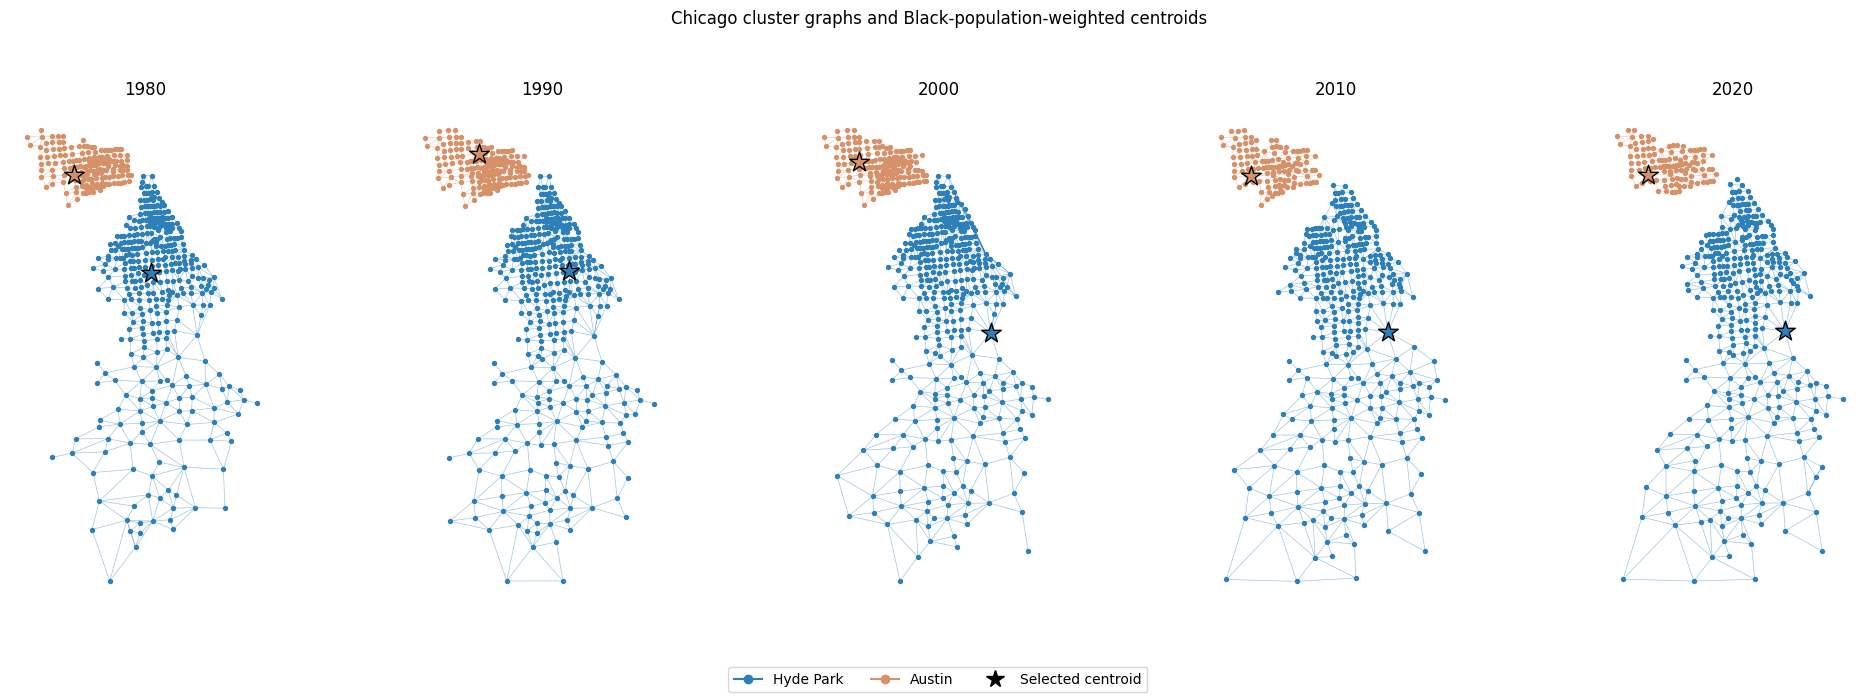

PosixPath('figures/chicago_cluster_centroids_all_years.png')

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Read the saved catchments and centroids for Chicago
chicago_selections = pd.read_csv(
    'data/candidate_tracts.csv', dtype={'cbsa': str, 'gisjoin': str}
)
chicago_metrics = pd.read_csv(
    'data/cluster_metrics.csv',
    dtype={'cbsa': str, 'center_gisjoin': str},
)
chicago_selections = chicago_selections[chicago_selections['cbsa'] == '16980']
chicago_metrics = chicago_metrics[chicago_metrics['cbsa'] == '16980']
years = sorted(chicago_metrics['year'].unique())
colors = {'hyde_park': '#2c7fb8', 'austin': "#d69169"}

# Draw each selected catchment graph
fig, axes = plt.subplots(1, len(years), figsize=(20, 7))
for ax, year in zip(axes, years):
    graph_path = next(
        (Path('../../data/processed/dual_graphs') / str(year)).glob(
            f'tracts_in_cbsa_16980_{year}_*_connected.json'
        )
    )
    graph = gerrychain.Graph.from_json(graph_path)
    nodes_by_gisjoin = {
        str(attrs['GISJOIN']): node for node, attrs in graph.nodes(data=True)
    }
    # places each tract node at its real geographic centroid, so the graph resembles Chicago’s actual geography:
    positions = {
        node: (float(attrs['centroid_x']), float(attrs['centroid_y']))
        for node, attrs in graph.nodes(data=True)
    }

    year_selections = chicago_selections[chicago_selections['year'] == year]
    for cluster, group in year_selections.groupby('cluster'):
        # print(cluster, group)
        selected_nodes = [nodes_by_gisjoin[value] for value in group['gisjoin']]
        selected_graph = graph.subgraph(selected_nodes)
        nx.draw_networkx_edges(
            selected_graph, positions, ax=ax, edge_color=colors[cluster],
            width=0.5, alpha=0.45)
        nx.draw_networkx_nodes(
            selected_graph, positions, ax=ax, node_color=colors[cluster],
            node_size=8)

        centroid_gisjoin = chicago_metrics.loc[
            (chicago_metrics['year'] == year)
            & (chicago_metrics['cluster'] == cluster),
            'center_gisjoin',
        ].iloc[0]
        centroid_x, centroid_y = positions[nodes_by_gisjoin[centroid_gisjoin]]
        ax.scatter(
            centroid_x, centroid_y, marker='*', s=220, color=colors[cluster],
            edgecolor='black', linewidth=1.0, zorder=3
        )

    ax.set_title(str(year))
    ax.set_aspect('equal')
    ax.axis('off')

# Add one shared legend and save the five-year figure.
legend_items = [
    Line2D([0], [0], color=colors['hyde_park'], marker='o', linestyle='-', label='Hyde Park'),
    Line2D([0], [0], color=colors['austin'], marker='o', linestyle='-', label='Austin'),
    Line2D([0], [0], color='black', marker='*', markersize=13, linestyle='None', label='Selected centroid'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=3)
fig.suptitle('Chicago cluster graphs and Black-population-weighted centroids')
fig.tight_layout(rect=(0, 0.08, 1, 0.94))
Path('figures').mkdir(exist_ok=True)
figure_path = Path('figures/chicago_cluster_centroids_all_years.png')
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()
figure_path